# GB electricity demand: exploratory analysis

Run `gridcast ingest all` before this notebook.

Analysis logic lives in the `gridcast` package, not in this notebook: the
notebook only explores and plots. Anything worth keeping moves into the
package, where it is tested and can run in production.

In [1]:
import os
from pathlib import Path

# Notebooks start in notebooks/, but data paths are relative to the repo root.
root = next(d for d in [Path.cwd(), *Path.cwd().parents] if (d / "pyproject.toml").exists())
os.chdir(root)
print("working directory:", Path.cwd())

working directory: /workspaces/uk-grid-forecast


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from gridcast.config import get_settings
from gridcast.data import load_demand, load_generation, load_weather
from gridcast.features import FEATURE_COLUMNS, TARGET, build_features
from gridcast.features.weather import national_weather, to_half_hourly

plt.rcParams["figure.figsize"] = (12, 4)
settings = get_settings()

demand = load_demand(settings)
weather = load_weather(settings)

first = demand.timestamp_utc.min()
last = demand.timestamp_utc.max()
print(f"{len(demand):,} half hours")
print(f"{first:%Y-%m-%d} to {last:%Y-%m-%d}")
demand.tail()

65,343 half hours
2023-01-01 to 2026-09-23


,settlement_date,settlement_period,nd_mw,tsd_mw,england_wales_demand_mw,embedded_wind_generation_mw,embedded_wind_capacity_mw,embedded_solar_generation_mw,embedded_solar_capacity_mw,non_bm_stor_mw,...,ifa2_flow_mw,britned_flow_mw,moyle_flow_mw,east_west_flow_mw,nemo_flow_mw,nsl_flow_mw,eleclink_flow_mw,viking_flow_mw,greenlink_flow_mw,timestamp_utc
65338,2026-09-23,13,22374.0,26624.0,20765.0,1240.0,6417.0,0.0,23963.0,0.0,...,-607.0,-714.0,-149.0,0.0,0.0,1402.0,-723.0,-1155.0,-410.0,2026-09-23 05:00:00+00:00
65339,2026-09-23,14,23340.0,27751.0,21572.0,1332.0,6417.0,0.0,23963.0,0.0,...,-578.0,-708.0,-300.0,-80.0,0.0,1402.0,-714.0,-1132.0,-407.0,2026-09-23 05:30:00+00:00
65340,2026-09-23,15,25411.0,29331.0,23499.0,1347.0,6417.0,97.0,23963.0,0.0,...,-26.0,-638.0,-432.0,-231.0,0.0,1402.0,-677.0,-913.0,-510.0,2026-09-23 06:00:00+00:00
65341,2026-09-23,16,26946.0,30854.0,24912.0,1387.0,6417.0,545.0,23963.0,0.0,...,22.0,-630.0,-451.0,-377.0,0.0,1397.0,-594.0,-853.0,-514.0,2026-09-23 06:30:00+00:00
65342,2026-09-23,17,28302.0,30360.0,25973.0,1407.0,6417.0,1237.0,23963.0,0.0,...,546.0,-209.0,-451.0,-510.0,0.0,1353.0,628.0,71.0,-514.0,2026-09-23 07:00:00+00:00


## 1. The shape of demand

Three cycles sit on top of each other: daily, weekly and yearly.

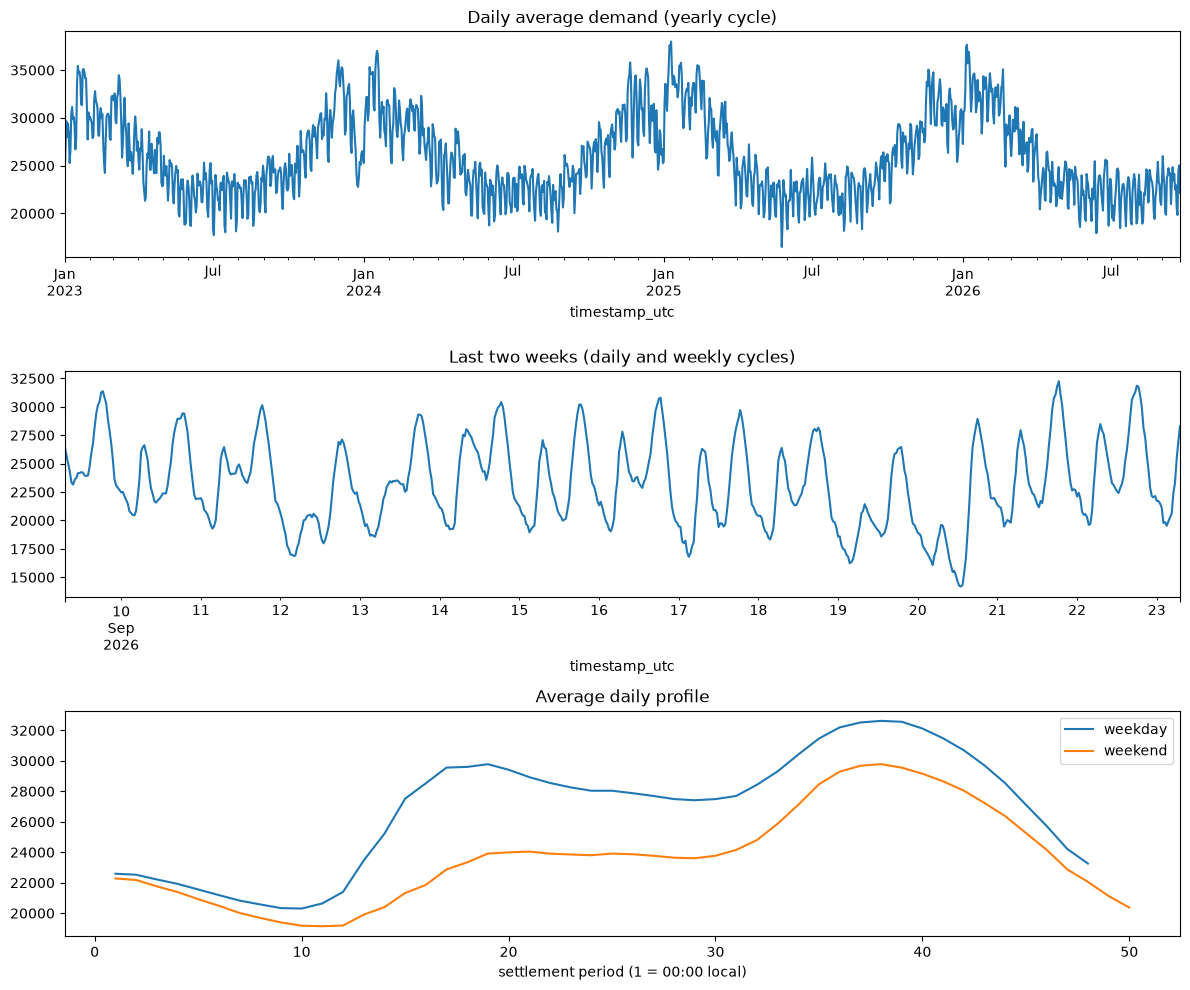

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

daily_mean = demand.set_index("timestamp_utc")["nd_mw"].resample("D").mean()
daily_mean.plot(ax=axes[0], title="Daily average demand (yearly cycle)")

two_weeks = demand[demand.timestamp_utc >= last - pd.Timedelta(days=14)]
two_weeks.set_index("timestamp_utc")["nd_mw"].plot(
    ax=axes[1], title="Last two weeks (daily and weekly cycles)"
)

is_weekend = demand.settlement_date.dt.dayofweek >= 5
profile = (
    demand.assign(weekend=is_weekend)
    .groupby(["settlement_period", "weekend"])["nd_mw"]
    .mean()
    .unstack()
)
profile.columns = ["weekday", "weekend"]
profile.plot(ax=axes[2], title="Average daily profile")
axes[2].set_xlabel("settlement period (1 = 00:00 local)")
plt.tight_layout()

## 2. Temperature drives demand

The relationship is a hockey stick, not a straight line. That is why the
feature table has heating and cooling degree days rather than raw temperature.

Text(0.5, 1.0, 'Demand vs temperature')

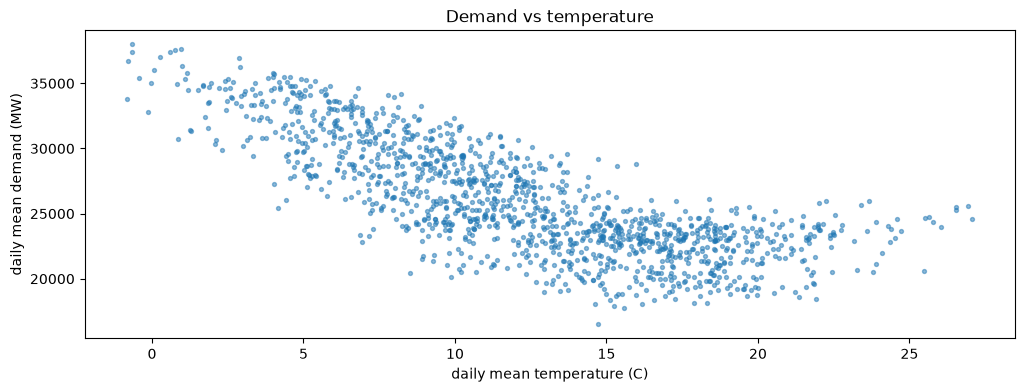

In [4]:
national = national_weather(weather)
index = pd.DatetimeIndex(demand.timestamp_utc)
aligned = to_half_hourly(national, index).reset_index(drop=True)

joined = pd.concat(
    [demand.reset_index(drop=True)[["timestamp_utc", "nd_mw"]], aligned],
    axis=1,
).dropna()

daily = (
    joined.set_index("timestamp_utc").resample("D").agg({"nd_mw": "mean", "temperature_2m": "mean"})
)

plt.scatter(daily.temperature_2m, daily.nd_mw, s=8, alpha=0.5)
plt.xlabel("daily mean temperature (C)")
plt.ylabel("daily mean demand (MW)")
plt.title("Demand vs temperature")

## 3. Where the electricity comes from

The supply side, from Elexon. Note how variable wind is compared with nuclear.

Text(0, 0.5, 'MW')

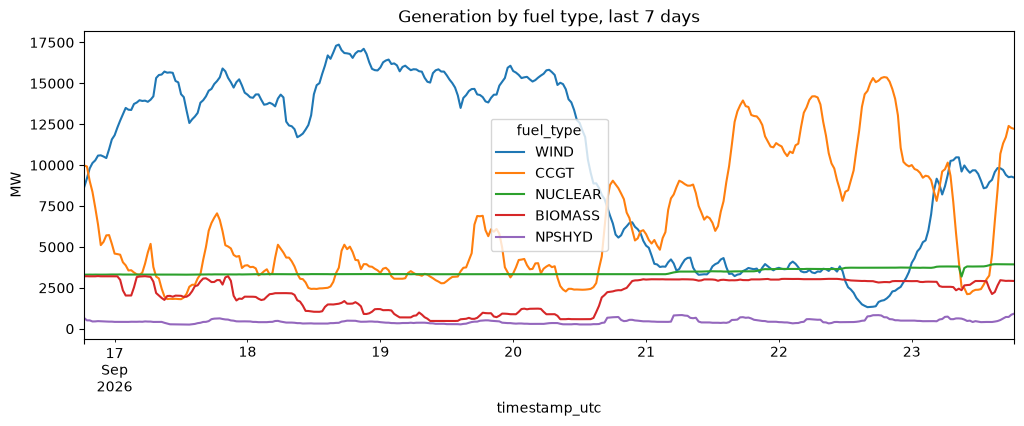

In [5]:
generation = load_generation(settings)
cutoff = generation.timestamp_utc.max() - pd.Timedelta(days=7)
recent = generation[generation.timestamp_utc >= cutoff]

wide = recent.pivot_table(index="timestamp_utc", columns="fuel_type", values="generation_mw")
main_fuels = ["WIND", "CCGT", "NUCLEAR", "BIOMASS", "NPSHYD"]
wide[[c for c in main_fuels if c in wide.columns]].plot(
    title="Generation by fuel type, last 7 days"
)
plt.ylabel("MW")

## 4. Net demand: the real problem

Net demand is what dispatchable plant must cover: demand minus wind and solar.
As renewables grow, forecasting this matters more than forecasting gross demand.

Text(0, 0.5, 'MW')

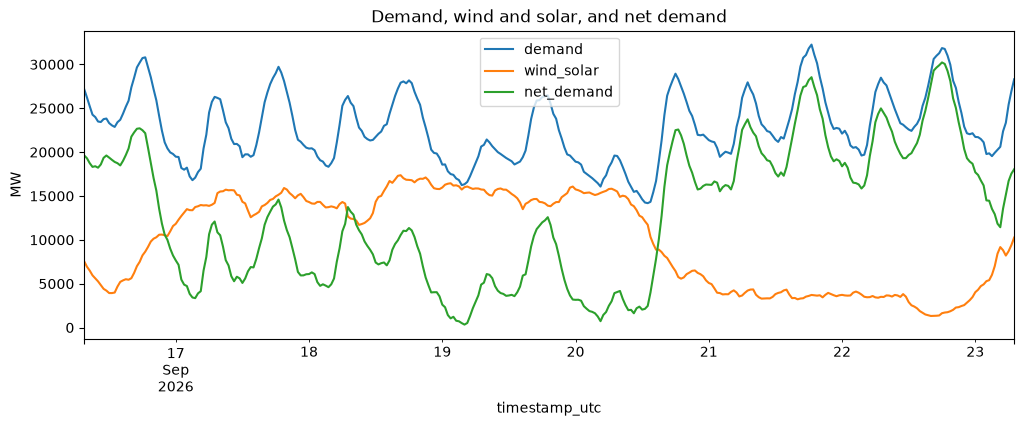

In [6]:
weather_driven = (
    generation[generation.fuel_type.isin(["WIND", "SOLAR"])]
    .groupby("timestamp_utc")["generation_mw"]
    .sum()
    .rename("wind_solar")
)

net = (
    demand.set_index("timestamp_utc")["nd_mw"].to_frame("demand").join(weather_driven, how="inner")
)
net["net_demand"] = net.demand - net.wind_solar

net.tail(7 * 48).plot(title="Demand, wind and solar, and net demand")
plt.ylabel("MW")

## 5. The feature table

What the model will actually learn from.

In [7]:
features = build_features(demand, weather)
print(features.shape)
features.head()

2026-09-23 21:36:13 [info     ] features.built                 dropped_incomplete=710 rows=64633
(64633, 37)


,timestamp_utc,settlement_date,settlement_period,nd_mw,day_of_week,month,day_of_year,is_weekend,day_fraction,time_of_day_sin,...,shortwave_radiation,relative_humidity_2m,nd_lag_2d_mw,nd_lag_3d_mw,nd_lag_7d_mw,nd_lag_14d_mw,nd_lag_week_mean_mw,nd_prev_day_mean_mw,nd_prev_day_max_mw,nd_prev_day_min_mw
0,2023-01-15 00:00:00+00:00,2023-01-15,1,21546.0,6,1,15,1,0.000000,0.000000,...,0.0,72.390,21775.0,23066.0,20573.0,21043.0,20808.0,29244.958333,37936.0,19420.0
1,2023-01-15 00:30:00+00:00,2023-01-15,2,21917.0,6,1,15,1,0.020833,0.130526,...,0.0,72.775,21911.0,23388.0,21360.0,21756.0,21558.0,29244.958333,37936.0,19420.0
2,2023-01-15 01:00:00+00:00,2023-01-15,3,21330.0,6,1,15,1,0.041667,0.258819,...,0.0,73.160,21311.0,23105.0,20932.0,21348.0,21140.0,29244.958333,37936.0,19420.0
3,2023-01-15 01:30:00+00:00,2023-01-15,4,20760.0,6,1,15,1,0.062500,0.382683,...,0.0,73.660,20963.0,22312.0,20337.0,20586.0,20461.5,29244.958333,37936.0,19420.0
4,2023-01-15 02:00:00+00:00,2023-01-15,5,20296.0,6,1,15,1,0.083333,0.500000,...,0.0,74.160,20645.0,21784.0,19959.0,19781.0,19870.0,29244.958333,37936.0,19420.0


<Axes: title={'center': 'Correlation with demand'}>

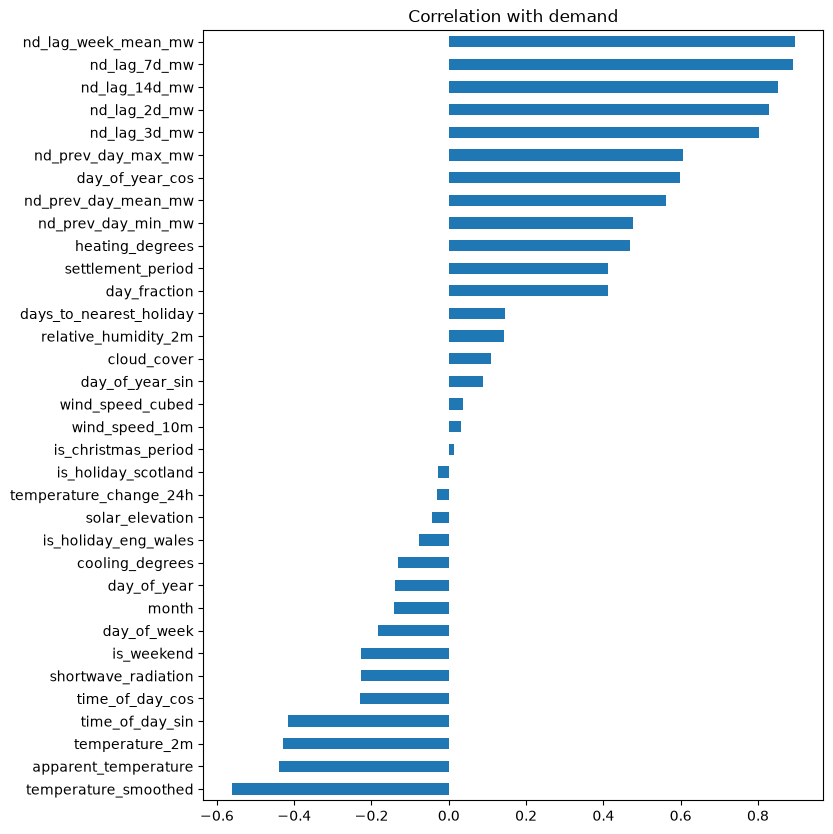

In [8]:
# Which features move with demand? A first look, not the final word:
# correlation only sees straight-line relationships.
correlations = features[[TARGET, *FEATURE_COLUMNS]].corr()[TARGET].drop(TARGET).sort_values()
correlations.plot.barh(figsize=(8, 10), title="Correlation with demand")